# AML s26 - 1D Regression with a Shallow Neural Network in PyTorch

First, install PyTorch:
>    conda install -c conda-forge pytorch

This notebook converts the 1D regression problem from `3_1_Shallow_Networks_I.ipynb` into PyTorch and solves it using backpropagation.

**Network architecture:** 1 input → 3 hidden units (ReLU) → 1 output  
**Loss:** Mean squared error (least squares)  
**Optimizer:** SGD / Adam


In [46]:
#!conda install -c conda-forge pytorch -y
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

### Training data

Same training data

In [47]:
x_train_np = np.array([0.09291784, 0.46809093, 0.93089486, 0.67612654, 0.73441752,
                        0.86847339, 0.49873225, 0.51083168, 0.18343972, 0.99380898,
                        0.27840809, 0.38028817, 0.12055708, 0.56715537, 0.92005746,
                        0.77072270, 0.85278176, 0.05315950, 0.87168699, 0.58858043])

y_train_np = np.array([-0.15934537,  0.18195445,  0.45127015,  0.13921448,  0.09366691,
                         0.30567674,  0.37229117,  0.40716968, -0.08131792,  0.41187806,
                         0.36943738,  0.39943270,  0.01906257,  0.35820410,  0.45256496,
                        -0.01831210,  0.02957665, -0.24354444,  0.14803884,  0.26824970])

# Convert to PyTorch tensors  (shape: [N, 1] for the network)
X = torch.tensor(x_train_np, dtype=torch.float32).unsqueeze(1)  # (20, 1)
Y = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)  # (20, 1)

print(f"X shape: {X.shape}, Y shape: {Y.shape}")

X shape: torch.Size([20, 1]), Y shape: torch.Size([20, 1])


### Define the neural network

The shallow network has:
- **Input layer**: 1 neuron
- **Hidden layer**: 3 neurons with ReLU activation
- **Output layer**: 1 neuron (linear)



In [48]:
class ShallowNet(nn.Module):
    """1-input, 5-hidden-ReLU, 1-output shallow network."""

    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 5)   # theta weights + biases
        self.output = nn.Linear(5, 1)   # phi weights + bias

    def forward(self, x):
        h = torch.relu(self.hidden(x))  # ReLU activations
        return self.output(h)


#torch.manual_seed(2)  # reproducibility

model = ShallowNet()

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

ShallowNet(
  (hidden): Linear(in_features=1, out_features=5, bias=True)
  (output): Linear(in_features=5, out_features=1, bias=True)
)

Total parameters: 16


### Train the network using backpropagation

We use **Adam** (adaptive learning rate) and **MSE loss** (equivalent to the
least-squares objective divided by N).

In [49]:
# Loss and optimiser
criterion = nn.MSELoss(reduction='sum')   # sum of squared residuals (matches notebook)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
n_epochs = 3000
loss_history = []

for epoch in range(n_epochs):
    # -------- Forward pass --------
    y_pred = model(X)
    loss   = criterion(y_pred, Y)

    # -------- Backward pass -------
    optimizer.zero_grad()   # clear gradients from previous step
    loss.backward()         # compute gradients via backprop
    optimizer.step()        # update parameters

    loss_history.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4f}")

print(f"\nFinal loss: {loss.item():.4f}")
print("(Original notebook best-by-hand loss was 0.181)")

Epoch     0 | Loss: 1.6413
Epoch    10 | Loss: 0.8406
Epoch    20 | Loss: 0.8592
Epoch    30 | Loss: 0.7632
Epoch    40 | Loss: 0.7100
Epoch    50 | Loss: 0.6719
Epoch    60 | Loss: 0.6513
Epoch    70 | Loss: 0.6465
Epoch    80 | Loss: 0.6453
Epoch    90 | Loss: 0.6453
Epoch   100 | Loss: 0.6452
Epoch   110 | Loss: 0.6452
Epoch   120 | Loss: 0.6452
Epoch   130 | Loss: 0.6452
Epoch   140 | Loss: 0.6452
Epoch   150 | Loss: 0.6452
Epoch   160 | Loss: 0.6452
Epoch   170 | Loss: 0.6452
Epoch   180 | Loss: 0.6452
Epoch   190 | Loss: 0.6452
Epoch   200 | Loss: 0.6452
Epoch   210 | Loss: 0.6452
Epoch   220 | Loss: 0.6452
Epoch   230 | Loss: 0.6452
Epoch   240 | Loss: 0.6452
Epoch   250 | Loss: 0.6452
Epoch   260 | Loss: 0.6452
Epoch   270 | Loss: 0.6452
Epoch   280 | Loss: 0.6452
Epoch   290 | Loss: 0.6452
Epoch   300 | Loss: 0.6452
Epoch   310 | Loss: 0.6452
Epoch   320 | Loss: 0.6452
Epoch   330 | Loss: 0.6452
Epoch   340 | Loss: 0.6452
Epoch   350 | Loss: 0.6452
Epoch   360 | Loss: 0.6452
E

### Plot training loss

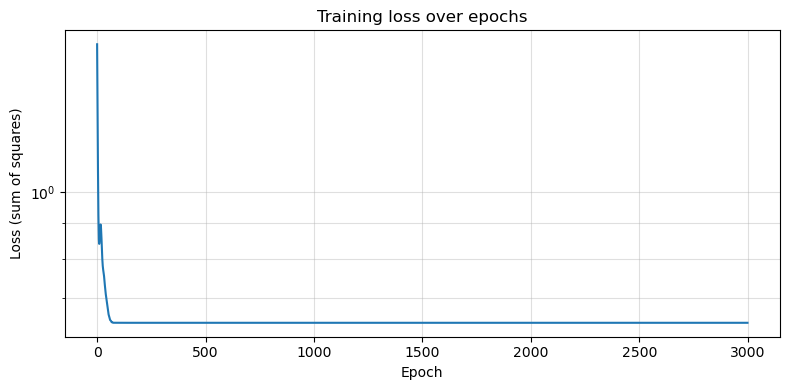

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (sum of squares)')
plt.title('Training loss over epochs')
plt.yscale('log')
plt.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

### Plot the fitted model vs. training data

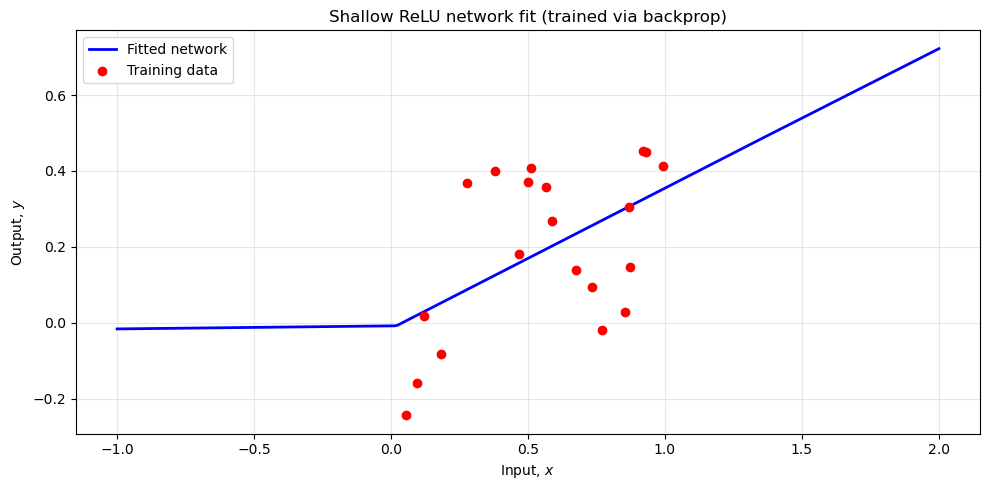

In [51]:
x_plot = torch.linspace(-1.0, 2.0, 300).unsqueeze(1)

model.eval()
with torch.no_grad():
    y_plot = model(x_plot).squeeze().numpy()

plt.figure(figsize=(10, 5))
plt.plot(x_plot.numpy(), y_plot, 'b-', linewidth=2, label='Fitted network')
plt.scatter(x_train_np, y_train_np, color='red', zorder=5, label='Training data')
plt.xlabel('Input, $x$')
plt.ylabel('Output, $y$')
plt.title('Shallow ReLU network fit (trained via backprop)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Inspect learned parameters

These correspond directly to the $\theta$ and $\phi$ values in the notebook.

In [52]:
with torch.no_grad():
    theta_weights = model.hidden.weight.numpy()  # shape (3, 1)
    theta_biases  = model.hidden.bias.numpy()    # shape (3,)
    phi_weights   = model.output.weight.numpy()  # shape (1, 3)
    phi_bias      = model.output.bias.numpy()    # shape (1,)

print("Hidden layer (theta parameters):")
for i in range(3):
    print(f"  Unit {i+1}: theta_{i+1}0 (bias)   = {theta_biases[i]:+.4f}")
    print(f"           theta_{i+1}1 (weight) = {theta_weights[i, 0]:+.4f}")

print("\nOutput layer (phi parameters):")
print(f"  phi_0 (bias)   = {phi_bias[0]:+.4f}")
for j in range(3):
    print(f"  phi_{j+1} (weight) = {phi_weights[0, j]:+.4f}")

Hidden layer (theta parameters):
  Unit 1: theta_10 (bias)   = -0.9348
           theta_11 (weight) = -0.6576
  Unit 2: theta_20 (bias)   = -0.0135
           theta_21 (weight) = +0.6924
  Unit 3: theta_30 (bias)   = -0.6321
           theta_31 (weight) = -0.0379

Output layer (phi parameters):
  phi_0 (bias)   = +0.1616
  phi_1 (weight) = -0.4453
  phi_2 (weight) = +0.5228
  phi_3 (weight) = +0.1942
